In [1]:
import pandas as pd

df = pd.read_csv("../data/customer_support_tickets.csv")

print("Dataset loaded successfully")
print(df.shape)

Dataset loaded successfully
(8469, 17)


In [2]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')


In [3]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['Ticket Description'].apply(clean_text)

print(df[['Ticket Description', 'clean_text']].head())

                                  Ticket Description  \
0  I'm having an issue with the {product_purchase...   
1  I'm having an issue with the {product_purchase...   
2  I'm facing a problem with my {product_purchase...   
3  I'm having an issue with the {product_purchase...   
4  I'm having an issue with the {product_purchase...   

                                          clean_text  
0  im having an issue with the productpurchased p...  
1  im having an issue with the productpurchased p...  
2  im facing a problem with my productpurchased t...  
3  im having an issue with the productpurchased p...  
4  im having an issue with the productpurchased p...  


In [4]:
print(type(df))

<class 'pandas.DataFrame'>


In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['Ticket Description'].apply(clean_text)

print("Text cleaning completed")

Text cleaning completed


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

print("TF-IDF completed")

TF-IDF completed


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

y = df['Ticket Type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Model trained successfully")

Model trained successfully


In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.18181818181818182


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.14      0.09      0.11       357
Cancellation request       0.19      0.23      0.21       327
     Product inquiry       0.19      0.19      0.19       316
      Refund request       0.17      0.19      0.18       345
     Technical issue       0.21      0.21      0.21       349

            accuracy                           0.18      1694
           macro avg       0.18      0.18      0.18      1694
        weighted avg       0.18      0.18      0.18      1694



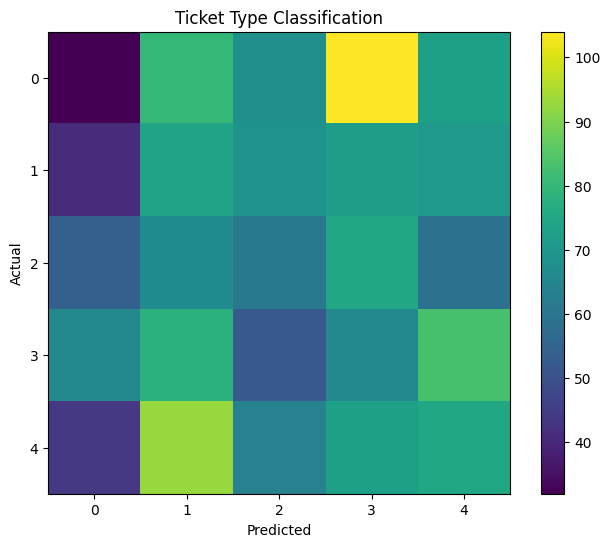

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)

plt.title("Ticket Type Classification")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/confusion_matrix.png")

plt.show()

In [11]:
print(df["Ticket Type"].value_counts())

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [12]:
print("Unique Categories:", df["Ticket Type"].nunique())

Unique Categories: 5


In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.1894923258559622


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_priority = df["Ticket Priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

priority_model = LogisticRegression(max_iter=1000)

priority_model.fit(X_train_p, y_train_p)

priority_pred = priority_model.predict(X_test_p)

priority_accuracy = accuracy_score(
    y_test_p,
    priority_pred
)

print("Priority Accuracy:", priority_accuracy)

Priority Accuracy: 0.26741440377804016


In [17]:
print(df["Ticket Type"].value_counts())

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64
